# EDA of the bina.az sale data (exploration notebook)

This notebook records how the cleaning rules were chosen. The reproducible versions used by the
pipeline are `src/data_prep.py` (cleaning, split, encoding) and `src/eda.py` (Figures 1–4):
`python -m src.eda --data data/house_sale.csv` writes the figures to `report/figures/`.
Run this notebook from the repo root. Numbers here can differ slightly from the pipeline,
which splits with NumPy instead of scikit-learn.

In [ ]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Display settings: show all columns, readable numbers
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid")

# Load raw data
DATA_PATH = "data/house_sale.csv"  # run from the repo root
df_raw = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Raw shape: {df_raw.shape}")
# Identifier / personal columns are hidden: the repo is public
PERSONAL = ["owner_name", "owner_title", "shop_name", "shop_title", "address", "description", "img_url"]
df_raw.drop(columns=PERSONAL).head(3)

Raw shape: (100775, 51)


In [ ]:
# Sanity checks on raw data
# Currency: are all prices in AZN?
print("=== currency_x ===")
print(df_raw["currency_x"].value_counts(dropna=False))
print("\n=== currency_y ===")
print(df_raw["currency_y"].value_counts(dropna=False))

# Duplicates: same listing appearing more than once
print("\n=== Duplicates ===")
print("Duplicated listing URLs:", df_raw["estate_rel_url_x"].duplicated().sum())
print("Fully duplicated rows:  ", df_raw.duplicated().sum())

# Category vs building type: where is the property type stored?
print("\n=== Kateqoriya ===")
print(df_raw["Kateqoriya"].value_counts(dropna=False))
print("\n=== Binanın növü ===")
print(df_raw["Binanın növü"].value_counts(dropna=False))

# Do these column pairs carry the same information?
for a, b in [("repair", "Təmir"), ("bill_of_sale", "Çıxarış"), ("mortgage", "İpoteka")]:
    print(f"\n=== {a} vs {b} ===")
    print(pd.crosstab(df_raw[a].fillna("NaN"), df_raw[b].fillna("NaN")))

# Units inside area columns
print("\n=== Units in Sahə ===")
print(df_raw["Sahə"].astype(str).str.replace(r"[\d.,\s]", "", regex=True).value_counts())
print("\n=== Units in Torpaq sahəsi ===")
print(df_raw["Torpaq sahəsi"].astype(str).str.replace(r"[\d.,\s]", "", regex=True).value_counts())

# Share of missing values per column (top 25)
print("\n=== Missing ratio ===")
print(df_raw.isna().mean().sort_values(ascending=False).head(25))

=== currency_x ===
currency_x
AZN    100775
Name: count, dtype: int64

=== currency_y ===
currency_y
AZN    100775
Name: count, dtype: int64

=== Duplicates ===
Duplicated listing URLs: 36321
Fully duplicated rows:   0

=== Kateqoriya ===
Kateqoriya
Yeni tikili          57897
Köhnə tikili         18099
Həyət evi/Bağ evi    15571
Torpaq                4919
Obyekt                4046
Ofis                   154
Qaraj                   89
Name: count, dtype: int64

=== Binanın növü ===
Binanın növü
NaN               100621
Ev / Mənzil           85
Biznes mərkəzi        64
Villa                  5
Name: count, dtype: int64

=== repair vs Təmir ===
Təmir     NaN    var  yoxdur
repair                      
NaN      6001      0   13162
Təmirli     0  81612       0

=== bill_of_sale vs Çıxarış ===
Çıxarış         var  yoxdur
bill_of_sale               
NaN               0   21210
Çıxarış var   79565       0

=== mortgage vs İpoteka ===
İpoteka        NaN    var
mortgage                 
NaN    

In [4]:
# Inspect duplicated listings before removing them
dup_mask = df_raw["estate_rel_url_x"].duplicated(keep=False)
dups = df_raw[dup_mask]

print("Rows involved in duplication:", dup_mask.sum())
print("Unique listings among them:  ", dups["estate_rel_url_x"].nunique())
print("\nCopies per listing:")
print(dups["estate_rel_url_x"].value_counts().value_counts().sort_index())

# Does the price change between copies of the same listing?
price_nunique = dups.groupby("estate_rel_url_x")["price"].nunique()
print("\nListings whose price changed between copies:", (price_nunique > 1).sum())

# Scrape timestamps: are copies from different scrape runs?
print("\nScrape times (datetime_scrape_y) sample:")
print(dups.sort_values("estate_rel_url_x")[["estate_rel_url_x", "datetime_scrape_y", "price"]].head(10))

Rows involved in duplication: 56827
Unique listings among them:   20506

Copies per listing:
count
2     12321
3      4353
4      1949
5       934
6       453
7       243
8       120
9        83
10       32
11       10
12        4
13        3
17        1
Name: count, dtype: int64

Listings whose price changed between copies: 3356

Scrape times (datetime_scrape_y) sample:
      estate_rel_url_x              datetime_scrape_y      price
9285    /items/1005812  2024-10-09 05:02:29.349209+00  23,500.00
92189   /items/1005812     2024-11-13 20:51:47.165261  23,500.00
21008   /items/1005812  2024-10-12 05:53:49.164398+00  23,500.00
4332    /items/1005812  2024-10-08 07:35:53.717949+00  23,500.00
3208    /items/1151874  2024-10-05 22:14:10.089116+00 600,000.00
19962   /items/1151874  2024-10-11 08:37:27.966827+00 600,000.00
53909   /items/1151874     2024-10-20 20:46:55.684395 600,000.00
78240   /items/1151874     2024-11-05 20:53:56.783575 600,000.00
12854   /items/1151874  2024-10-09 05:02:

In [5]:
# Cell 4: Remove duplicated listings, keeping the most recent scrape
df = df_raw.copy()

# Parse scrape timestamps (mixed formats: some with '+00', some without)
df["scraped_at"] = pd.to_datetime(df["datetime_scrape_y"], format="mixed", utc=True)
print("Unparsed timestamps:", df["scraped_at"].isna().sum())

# Sort by listing, then by time; keep the last (latest) copy of each listing
df = (df.sort_values(["estate_rel_url_x", "scraped_at"]).drop_duplicates(subset="estate_rel_url_x", keep="last").reset_index(drop=True))

print(f"Shape after de-duplication: {df.shape}")
print("Remaining duplicated listing URLs:", df["estate_rel_url_x"].duplicated().sum())

Unparsed timestamps: 0
Shape after de-duplication: (64454, 52)
Remaining duplicated listing URLs: 0


In [6]:
# Price and area by property category (after de-duplication)
# Area as number + its unit, to confirm 'sot' only appears for land
area_unit = df["Sahə"].astype(str).str.replace(r"[\d.,\s]", "", regex=True)
summary = (
    df.assign(area_unit=area_unit)
      .groupby("Kateqoriya")
      .agg(
          n_listings=("price", "size"),
          price_median=("price", "median"),
          price_min=("price", "min"),
          price_max=("price", "max"),
          rooms_missing=("Otaq sayı", lambda s: s.isna().mean()),
          floor_missing=("Mərtəbə", lambda s: s.isna().mean()),
          units=("area_unit", lambda s: ", ".join(sorted(s.unique()))),
      )
      .sort_values("n_listings", ascending=False)
)
print(summary)
print("\nTotal:", summary["n_listings"].sum())

                   n_listings  price_median  price_min      price_max  \
Kateqoriya                                                              
Yeni tikili             36667    240,000.00      73.00 600,000,000.00   
Köhnə tikili            12153    145,000.00     700.00   3,400,000.00   
Həyət evi/Bağ evi        9632    205,000.00     127.00  12,000,000.00   
Torpaq                   3315    140,000.00     800.00  40,000,000.00   
Obyekt                   2526    560,000.00      11.00  36,000,000.00   
Ofis                      101    494,999.00  32,000.00   5,780,000.00   
Qaraj                      60     29,750.00   8,500.00   1,500,000.00   

                   rooms_missing  floor_missing units  
Kateqoriya                                             
Yeni tikili                 0.00           0.00    m²  
Köhnə tikili                0.00           0.00    m²  
Həyət evi/Bağ evi           0.02           1.00    m²  
Torpaq                      1.00           1.00   sot  
Obyekt

In [7]:
# Parsing area columns (m2 vs sot), then inspect price tails per category

def to_number(series: pd.Series) -> pd.Series:
    """'145 m²' -> 145.0, '1.3 sot' -> 1.3, '1 250 m²' -> 1250.0"""
    cleaned = (
        series.astype(str)
              .str.replace(r"[^\d.,]", "", regex=True)  # keep digits, dot, comma
              .str.replace(",", ".", regex=False)
    )
    return pd.to_numeric(cleaned, errors="coerce")

area_raw = to_number(df["Sahə"])
is_sot = df["Sahə"].astype(str).str.contains("sot")

# Building area in m2 (land plots have no building -> 0)
df["area_m2"] = np.where(is_sot, 0.0, area_raw)

# Land area in sot: land plots take it from 'Sahə', houses from 'Torpaq sahəsi'
df["land_area_sot"] = np.where(is_sot, area_raw, to_number(df["Torpaq sahəsi"]))

print("Rows with area in sot:", is_sot.sum(), "| Torpaq rows:", (df["Kateqoriya"] == "Torpaq").sum())
print("Unparsed area_m2:", pd.isna(df["area_m2"]).sum())
print("land_area_sot missing by category:")
print(df.groupby("Kateqoriya")["land_area_sot"].apply(lambda s: s.isna().mean()).round(2))

# Price quantiles per category (to choose outlier rules)
q = [0, 0.001, 0.01, 0.5, 0.99, 0.999, 1]
print("\n=== Price quantiles per category ===")
print(df.groupby("Kateqoriya")["price"].quantile(q).unstack().round(0))

cols = ["Kateqoriya", "price", "area_m2", "land_area_sot", "Otaq sayı", "location"]
print("\n=== 10 cheapest ===")
print(df.nsmallest(10, "price")[cols])
print("\n=== 10 most expensive ===")
print(df.nlargest(10, "price")[cols])

Rows with area in sot: 3315 | Torpaq rows: 3315
Unparsed area_m2: 0
land_area_sot missing by category:
Kateqoriya
Həyət evi/Bağ evi   0.00
Köhnə tikili        1.00
Obyekt              1.00
Ofis                1.00
Qaraj               1.00
Torpaq              0.00
Yeni tikili         1.00
Name: land_area_sot, dtype: float64

=== Price quantiles per category ===
                       0.00      0.00      0.01       0.50          0.99  \
Kateqoriya                                                                 
Həyət evi/Bağ evi    127.00 18,316.00 30,000.00 205,000.00  2,250,000.00   
Köhnə tikili         700.00 39,000.00 66,000.00 145,000.00    550,000.00   
Obyekt                11.00 10,000.00 32,000.00 560,000.00  9,375,000.00   
Ofis              32,000.00 33,800.00 50,000.00 494,999.00  4,500,000.00   
Qaraj              8,500.00  8,588.00  9,385.00  29,750.00    674,000.00   
Torpaq               800.00  1,000.00  2,757.00 140,000.00 12,000,000.00   
Yeni tikili           73.00 3

In [8]:
# DRY RUN of outlier rules - count what each rule would remove (nothing is dropped yet)

has_building = df["area_m2"] > 0
is_land = df["Kateqoriya"] == "Torpaq"
residential = df["Kateqoriya"].isin(["Yeni tikili", "Köhnə tikili", "Həyət evi/Bağ evi"])

# Unit prices, used ONLY to detect data-entry errors, never as features
price_per_m2 = df["price"] / df["area_m2"].where(has_building)
price_per_sot = df["price"] / df["land_area_sot"].where(is_land)

print("=== Price per m2 quantiles (building categories) ===")
print(price_per_m2.groupby(df["Kateqoriya"]).quantile([0.001, 0.01, 0.5, 0.99, 0.999]).unstack().round(0))
print("\n=== Price per sot quantiles (land) ===")
print(price_per_sot.quantile([0.001, 0.01, 0.5, 0.99, 0.999]).round(0))

# Candidate fixed rules (domain knowledge, not learned from data)
rules = {
    "price < 5,000 AZN (any category)":           df["price"] < 5_000,
    "residential price < 15,000 AZN":             residential & (df["price"] < 15_000),
    "residential area < 15 or > 1,000 m2":        residential & ((df["area_m2"] < 15) | (df["area_m2"] > 1_000)),
    "price per m2 < 100 or > 15,000 AZN":         has_building & ((price_per_m2 < 100) | (price_per_m2 > 15_000)),
    "land area <= 0 or > 10,000 sot":             is_land & ((df["land_area_sot"] <= 0) | (df["land_area_sot"] > 10_000)),
}

print("\n=== Rows each rule would remove ===")
any_rule = pd.Series(False, index=df.index)
for name, mask in rules.items():
    mask = mask.fillna(False)
    any_rule |= mask
    print(f"{name:42s} {mask.sum():6d}")
print(f"{'TOTAL (union of all rules)':42s} {any_rule.sum():6d}  ({any_rule.mean():.2%})")

=== Price per m2 quantiles (building categories) ===
                    0.00     0.01     0.50      0.99      1.00
Kateqoriya                                                    
Həyət evi/Bağ evi 133.00   282.00 1,138.00  4,286.00  8,295.00
Köhnə tikili      661.00 1,146.00 2,250.00  4,667.00  7,646.00
Obyekt             21.00   228.00 3,204.00 20,000.00 51,010.00
Ofis               98.00   795.00 3,143.00  7,037.00  7,045.00
Qaraj             409.00   450.00 1,248.00  3,177.00  3,551.00
Torpaq               NaN      NaN      NaN       NaN       NaN
Yeni tikili       668.00 1,000.00 2,391.00  4,945.00  8,178.00

=== Price per sot quantiles (land) ===
0.00         6.00
0.01       150.00
0.50    13,333.00
0.99   212,500.00
1.00   533,333.00
dtype: float64

=== Rows each rule would remove ===
price < 5,000 AZN (any category)               82
residential price < 15,000 AZN                 12
residential area < 15 or > 1,000 m2            93
price per m2 < 100 or > 15,000 AZN             8

In [10]:
# Refined rules (category-aware) - still a DRY RUN

is_commercial = df["Kateqoriya"] == "Obyekt"
rules = {
    "price < 5,000 AZN (any category)":            df["price"] < 5_000,
    "residential price < 15,000 AZN":              residential & (df["price"] < 15_000),
    "residential area < 15 or > 1,000 m2":         residential & ((df["area_m2"] < 15) | (df["area_m2"] > 1_000)),
    # Non-commercial buildings: 100 - 15,000 AZN/m2
    "non-commercial price/m2 < 100 or > 15,000":   has_building & ~is_commercial & ((price_per_m2 < 100) | (price_per_m2 > 15_000)),
    # Commercial: wider upper bound (small central shops can be very expensive per m2)
    "commercial price/m2 < 100 or > 60,000":       is_commercial & ((price_per_m2 < 100) | (price_per_m2 > 60_000)),
    "land area <= 0 or > 10,000 sot":              is_land & ((df["land_area_sot"] <= 0) | (df["land_area_sot"] > 10_000)),
    "land price/sot < 50":                         is_land & (price_per_sot < 50),
}
any_rule = pd.Series(False, index=df.index)
per_rule = {}
for name, mask in rules.items():
    mask = mask.fillna(False)
    per_rule[name] = mask
    any_rule |= mask
# Rows removed per rule and per category
breakdown = pd.DataFrame({name: m.groupby(df["Kateqoriya"]).sum() for name, m in per_rule.items()}).T
breakdown["TOTAL"] = breakdown.sum(axis=1)
print(breakdown)
print(f"\nTOTAL rows to remove (union): {any_rule.sum()}  ({any_rule.mean():.2%})")
print("\nRemoved per category (union):")
print(any_rule.groupby(df["Kateqoriya"]).sum())

Kateqoriya                                 Həyət evi/Bağ evi  Köhnə tikili  \
price < 5,000 AZN (any category)                           2             1   
residential price < 15,000 AZN                             5             2   
residential area < 15 or > 1,000 m2                       72             2   
non-commercial price/m2 < 100 or > 15,000                 11             2   
commercial price/m2 < 100 or > 60,000                      0             0   
land area <= 0 or > 10,000 sot                             0             0   
land price/sot < 50                                        0             0   

Kateqoriya                                 Obyekt  Ofis  Qaraj  Torpaq  \
price < 5,000 AZN (any category)                2     0      0      73   
residential price < 15,000 AZN                  0     0      0       0   
residential area < 15 or > 1,000 m2             0     0      0       0   
non-commercial price/m2 < 100 or > 15,000       0     1      0       0   
comme

In [11]:
# Inspecting the two largest groups flagged by the rules
cols = ["Kateqoriya", "price", "area_m2", "land_area_sot", "Otaq sayı", "location"]

# 1) Land plots under 5,000 AZN: real cheap rural land or errors?
cheap_land = df[is_land & (df["price"] < 5_000)].assign(price_per_sot=price_per_sot)
print("=== Land under 5,000 AZN ===")
print(cheap_land["price_per_sot"].describe().round(0))
print(cheap_land.sort_values("price")[cols + ["price_per_sot"]].head(15))

# 2) Houses with area < 15 or > 1,000 m2: tiny or huge?
odd_houses = df[residential & ((df["area_m2"] < 15) | (df["area_m2"] > 1_000))]
print("\n=== Residential with odd area ===")
print("Below 15 m2:", (odd_houses["area_m2"] < 15).sum(), "| Above 1,000 m2:", (odd_houses["area_m2"] > 1_000).sum())
print(odd_houses.sort_values("area_m2", ascending=False)[cols].head(15))

=== Land under 5,000 AZN ===
count      73.00
mean      528.00
std       620.00
min         0.00
25%       183.00
50%       400.00
75%       700.00
max     4,500.00
Name: price_per_sot, dtype: float64
      Kateqoriya    price  area_m2  land_area_sot  Otaq sayı         location  \
7052      Torpaq   800.00     0.00       2,500.00        NaN          Zirə q.   
28790     Torpaq 1,000.00     0.00           3.00        NaN           Xaçmaz   
28791     Torpaq 1,000.00     0.00           3.00        NaN           Xaçmaz   
59905     Torpaq 1,000.00     0.00           3.00        NaN           Xaçmaz   
49868     Torpaq 1,000.00     0.00          10.00        NaN       Hökməli q.   
60936     Torpaq 1,000.00     0.00         200.00        NaN         Şıxov q.   
52761     Torpaq 1,200.00     0.00           3.00        NaN       Maştağa q.   
48514     Torpaq 1,200.00     0.00          25.00        NaN   Ceyranbatan q.   
49387     Torpaq 1,200.00     0.00           3.00        NaN       Maş

In [ ]:
# Final outlier rules (fixed domain rules) - APPLY

rooms = df["Otaq sayı"]
area_per_room = df["area_m2"] / rooms.where(rooms > 0)

final_rules = {
    "price < 5,000 AZN (buildings)":              has_building & (df["price"] < 5_000),
    "residential price < 15,000 AZN":             residential & (df["price"] < 15_000),
    "residential area < 15 m2":                   residential & (df["area_m2"] < 15),
    "residential area per room > 300 m2":         residential & (area_per_room > 300),
    "non-commercial price/m2 < 100 or > 15,000":  has_building & ~is_commercial & ((price_per_m2 < 100) | (price_per_m2 > 15_000)),
    "commercial price/m2 < 100 or > 60,000":      is_commercial & ((price_per_m2 < 100) | (price_per_m2 > 60_000)),
    "land area <= 0 or > 10,000 sot":             is_land & ((df["land_area_sot"] <= 0) | (df["land_area_sot"] > 10_000)),
    "land price/sot < 50":                        is_land & (price_per_sot < 50),
}

to_drop = pd.Series(False, index=df.index)
outlier_log = []
for name, mask in final_rules.items():
    mask = mask.fillna(False)
    outlier_log.append({"rule": name, "rows_flagged": int(mask.sum())})
    to_drop |= mask

outlier_log = pd.DataFrame(outlier_log)
print(outlier_log.to_string(index=False))
print(f"\nRemoving {to_drop.sum()} rows ({to_drop.mean():.2%})")
print("Removed per category:")
print(to_drop.groupby(df["Kateqoriya"]).sum())

rows_before = len(df)
df = df[~to_drop].reset_index(drop=True)
print(f"\nShape: {rows_before} -> {df.shape[0]} rows")

In [12]:
# Final outlier rules
rooms = df["Otaq sayı"]
area_per_room = df["area_m2"] / rooms.where(rooms > 0)

final_rules = {
    "price < 5,000 AZN (buildings)":              has_building & (df["price"] < 5_000),
    "residential price < 15,000 AZN":             residential & (df["price"] < 15_000),
    "residential area < 15 m2":                   residential & (df["area_m2"] < 15),
    "residential area per room > 300 m2":         residential & (area_per_room > 300),
    "non-commercial price/m2 < 100 or > 15,000":  has_building & ~is_commercial & ((price_per_m2 < 100) | (price_per_m2 > 15_000)),
    "commercial price/m2 < 100 or > 60,000":      is_commercial & ((price_per_m2 < 100) | (price_per_m2 > 60_000)),
    "land area <= 0 or > 10,000 sot":             is_land & ((df["land_area_sot"] <= 0) | (df["land_area_sot"] > 10_000)),
    "land price/sot < 50":                        is_land & (price_per_sot < 50),
}

to_drop = pd.Series(False, index=df.index)
outlier_log = []
for name, mask in final_rules.items():
    mask = mask.fillna(False)
    outlier_log.append({"rule": name, "rows_flagged": int(mask.sum())})
    to_drop |= mask

outlier_log = pd.DataFrame(outlier_log)
print(outlier_log.to_string(index=False))
print(f"\nRemoving {to_drop.sum()} rows ({to_drop.mean():.2%})")
print("Removed per category:")
print(to_drop.groupby(df["Kateqoriya"]).sum())

rows_before = len(df)
df = df[~to_drop].reset_index(drop=True)
print(f"\nShape: {rows_before} -> {df.shape[0]} rows")

                                     rule  rows_flagged
            price < 5,000 AZN (buildings)             9
           residential price < 15,000 AZN            12
                 residential area < 15 m2            16
       residential area per room > 300 m2             8
non-commercial price/m2 < 100 or > 15,000            30
    commercial price/m2 < 100 or > 60,000            13
           land area <= 0 or > 10,000 sot             3
                      land price/sot < 50            16

Removing 81 rows (0.13%)
Removed per category:
Kateqoriya
Həyət evi/Bağ evi    17
Köhnə tikili          6
Obyekt               13
Ofis                  1
Qaraj                 0
Torpaq               18
Yeni tikili          26
dtype: int64

Shape: 64454 -> 64373 rows


In [13]:
# DRY RUN - hidden duplicates (same property, different listing URL)
base_key = ["Kateqoriya", "price", "area_m2", "land_area_sot", "Otaq sayı", "Mərtəbə"]
keys = {
    "A) base features only":               base_key,
    "B) base + exact coordinates":         base_key + ["lat", "lng"],
    "C) base + coordinates + description": base_key + ["lat", "lng", "description"],
}

for name, key in keys.items():
    dup = df.duplicated(subset=key, keep=False)       # all copies
    extra = df.duplicated(subset=key, keep="first")   # copies beyond the first
    print(f"{name:38s} rows in groups: {dup.sum():6d} | extra copies: {extra.sum():6d}")

# Look at a few groups under rule B
key_b = keys["B) base + exact coordinates"]
grp = df[df.duplicated(subset=key_b, keep=False)].sort_values(key_b)
print("\nSample of rule-B groups:")
print(grp[key_b + ["location", "estate_rel_url_x"]].head(12))
print("\nSame description inside rule-B groups:",
      grp.duplicated(subset=key_b + ["description"], keep=False).mean().round(2))

A) base features only                  rows in groups:  24130 | extra copies:  15734
B) base + exact coordinates            rows in groups:   1345 | extra copies:    699
C) base + coordinates + description    rows in groups:    712 | extra copies:    358

Sample of rule-B groups:
              Kateqoriya     price  area_m2  land_area_sot  Otaq sayı Mərtəbə  \
9359   Həyət evi/Bağ evi 37,000.00    60.00           0.70       2.00     NaN   
9378   Həyət evi/Bağ evi 37,000.00    60.00           0.70       2.00     NaN   
9914   Həyət evi/Bağ evi 37,000.00    60.00           0.70       2.00     NaN   
21774  Həyət evi/Bağ evi 42,000.00    70.00           1.00       3.00     NaN   
21775  Həyət evi/Bağ evi 42,000.00    70.00           1.00       3.00     NaN   
48201  Həyət evi/Bağ evi 45,000.00    75.00           1.50       3.00     NaN   
48432  Həyət evi/Bağ evi 45,000.00    75.00           1.50       3.00     NaN   
37422  Həyət evi/Bağ evi 45,000.00    90.00           1.50       3.00  

In [14]:
# (1) De-duplicate by numeric listing ID, 
# (2) remove exact re-posts (key C)
# 1) Extract numeric listing ID: '/items/4634576.html' -> 4634576
df["listing_id"] = df["estate_rel_url_x"].astype(str).str.extract(r"/items/(\d+)", expand=False)
print("Listings without a numeric ID:", df["listing_id"].isna().sum())
print("Duplicated listing IDs (missed by the URL check):", df["listing_id"].duplicated().sum())
rows_before = len(df)
df = (
    df.sort_values(["listing_id", "scraped_at"])
      .drop_duplicates(subset="listing_id", keep="last")
      .reset_index(drop=True)
)
removed_id_dups = rows_before - len(df)
# 2) Exact re-posts: same property, same coordinates, same description, different listing ID
key_c = ["Kateqoriya", "price", "area_m2", "land_area_sot", "Otaq sayı", "Mərtəbə", "lat", "lng", "description"]
rows_before = len(df)
df = (df.sort_values("scraped_at")
      .drop_duplicates(subset=key_c, keep="last")
      .reset_index(drop=True))
removed_reposts = rows_before - len(df)
print(f"\nRemoved by listing ID: {removed_id_dups}")
print(f"Removed as exact re-posts (key C): {removed_reposts}")
print(f"Shape now: {df.shape}")

Listings without a numeric ID: 0
Duplicated listing IDs (missed by the URL check): 669

Removed by listing ID: 669
Removed as exact re-posts (key C): 53
Shape now: (63651, 55)


In [ ]:
# Building the clean modelling table
# Rooms: filling missing values from the 'attributes' text ("4 otaqlı, 145 m²" -> 4)
rooms_from_text = pd.to_numeric(df["attributes"].astype(str).str.extract(r"(\d+)\s*otaqlı", expand=False), errors="coerce")
rooms = df["Otaq sayı"].fillna(rooms_from_text)

# Floor: "7 / 9" -> floor=7, total_floors=9 (allows basement floors like "-1 / 9")
floor_parts = df["Mərtəbə"].astype(str).str.extract(r"(-?\d+)\s*/\s*(\d+)")
floor = pd.to_numeric(floor_parts[0], errors="coerce")
total_floors = pd.to_numeric(floor_parts[1], errors="coerce")
clean = pd.DataFrame({
    "listing_id":       df["listing_id"],
    "price":            df["price"],
    "category":         df["Kateqoriya"],
    "area_m2":          df["area_m2"],
    "land_area_sot":    df["land_area_sot"],
    "rooms":            rooms,
    "floor":            floor,
    "total_floors":     total_floors,
    "repair":           df["Təmir"].map({"var": "yes", "yoxdur": "no"}).fillna("unknown"),
    "has_bill_of_sale": (df["Çıxarış"] == "var").astype(int),
    "mortgage":         (df["İpoteka"] == "var").astype(int),
    "is_vip":           df["vip"].notna().astype(int),
    "is_featured":      df["featured"].notna().astype(int),
    "city":             df["city"],
    "location":         df["location"],
    "lat":              df["lat"],
    "lng":              df["lng"],
})

print(f"Clean table shape: {clean.shape}")
print("\nMissing values per column:")
print(clean.isna().sum()[clean.isna().sum() > 0])
print("\nMissing rooms / floor by category:")
print(clean.groupby("category")[["rooms", "floor", "land_area_sot"]].apply(lambda g: g.isna().mean()).round(3))
print("\nRepair values:", clean["repair"].value_counts().to_dict())

Clean table shape: (63651, 17)

Missing values per column:
land_area_sot    50820
rooms             6038
floor            15502
total_floors     15502
dtype: int64

Missing rooms / floor by category:
                   rooms  floor  land_area_sot
category                                      
Həyət evi/Bağ evi   0.02   1.00           0.00
Köhnə tikili        0.00   0.00           1.00
Obyekt              1.00   1.00           1.00
Ofis                0.00   1.00           1.00
Qaraj               1.00   1.00           1.00
Torpaq              1.00   1.00           0.00
Yeni tikili         0.00   0.00           1.00

Repair values: {'yes': 51471, 'no': 8234, 'unknown': 3946}


In [16]:
# Filling structurally missing values with fixed rules, dropping truly unknown rooms
NO_ROOMS = ["Torpaq", "Obyekt", "Qaraj"]
# Fixed-rule fills
clean["land_area_sot"] = clean["land_area_sot"].fillna(0)
clean["floor"] = clean["floor"].fillna(0)
clean["total_floors"] = clean["total_floors"].fillna(0)
clean.loc[clean["category"].isin(NO_ROOMS), "rooms"] = clean.loc[clean["category"].isin(NO_ROOMS), "rooms"].fillna(0)

# Remaining missing rooms = houses with genuinely unknown room count -> drop
unknown_rooms = clean["rooms"].isna()
print("Rows with unknown rooms (dropped):")
print(clean.loc[unknown_rooms, "category"].value_counts())
clean = clean[~unknown_rooms].reset_index(drop=True)

# Integer types where it makes sense
for col in ["rooms", "floor", "total_floors"]:
    clean[col] = clean[col].astype(int)

# Safety checks: no missing values, no duplicated listing IDs
assert clean.isna().sum().sum() == 0, "There are still missing values!"
assert not clean["listing_id"].duplicated().any(), "Duplicated listing IDs!"
print(f"\nFinal clean shape: {clean.shape}")
print(clean.dtypes)

# Save a checkpoint so EDA can start from here
clean.to_csv("house_sale_clean.csv", index=False)
print("\nSaved: house_sale_clean.csv")

Rows with unknown rooms (dropped):
category
Həyət evi/Bağ evi    187
Name: count, dtype: int64

Final clean shape: (63464, 17)
listing_id           object
price               float64
category             object
area_m2             float64
land_area_sot       float64
rooms                 int64
floor                 int64
total_floors          int64
repair               object
has_bill_of_sale      int64
mortgage              int64
is_vip                int64
is_featured           int64
city                 object
location             object
lat                 float64
lng                 float64
dtype: object

Saved: house_sale_clean.csv


Listings: 63,464
Median price: 210,000 AZN | Mean price: 327,199 AZN
Skewness price: 19.78 | Skewness log(price): 0.20
99th percentile: 2,500,000 AZN (583 listings above it)


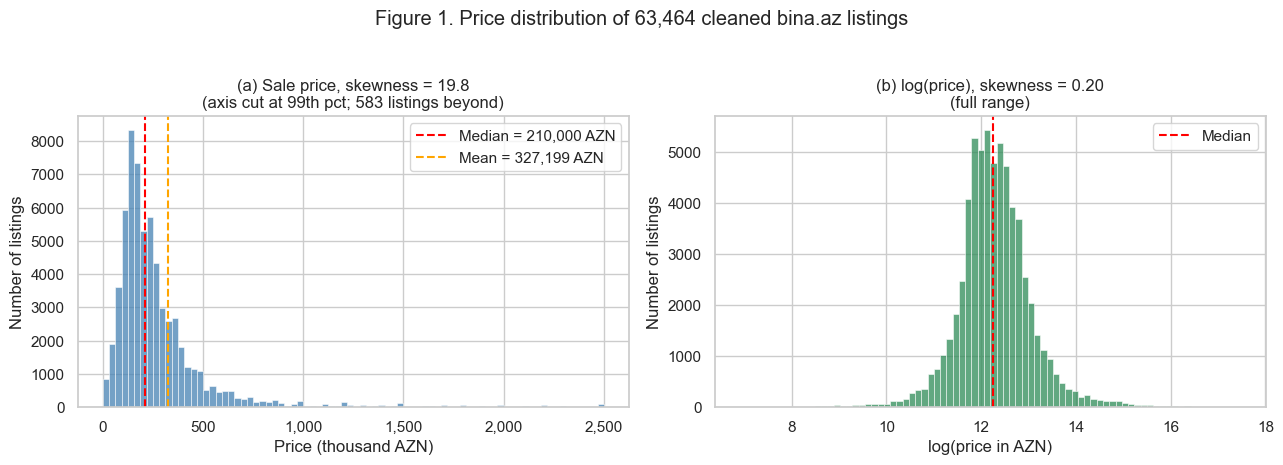

In [19]:
# Price distribution - raw vs log scale (Figure 1)
import os
from matplotlib.ticker import FuncFormatter
os.makedirs("report/figures", exist_ok=True)
clean["log_price"] = np.log(clean["price"])
price_skew = clean["price"].skew()
log_skew = clean["log_price"].skew()
price_median = clean["price"].median()
price_mean = clean["price"].mean()
p99 = clean["price"].quantile(0.99)
n_above = (clean["price"] > p99).sum()
print(f"Listings: {len(clean):,}")
print(f"Median price: {price_median:,.0f} AZN | Mean price: {price_mean:,.0f} AZN")
print(f"Skewness price: {price_skew:.2f} | Skewness log(price): {log_skew:.2f}")
print(f"99th percentile: {p99:,.0f} AZN ({n_above} listings above it)")
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# (a) Raw price, x-axis cut at the 99th percentile so the shape is visible
sns.histplot(clean.loc[clean["price"] <= p99, "price"], bins=80, ax=axes[0], color="steelblue")
axes[0].axvline(price_median, color="red", linestyle="--", label=f"Median = {price_median:,.0f} AZN")
axes[0].axvline(price_mean, color="orange", linestyle="--", label=f"Mean = {price_mean:,.0f} AZN")
axes[0].set_title(f"(a) Sale price, skewness = {price_skew:.1f}\n(axis cut at 99th pct; {n_above} listings beyond)")
axes[0].set_xlabel("Price (thousand AZN)")
axes[0].set_ylabel("Number of listings")
axes[0].xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x / 1e3:,.0f}"))
axes[0].legend()

# (b) log(price), full range
sns.histplot(clean["log_price"], bins=80, ax=axes[1], color="seagreen")
axes[1].axvline(np.log(price_median), color="red", linestyle="--", label="Median")
axes[1].set_title(f"(b) log(price), skewness = {log_skew:.2f}\n(full range)")
axes[1].set_xlabel("log(price in AZN)")
axes[1].set_ylabel("Number of listings")
axes[1].legend()

fig.suptitle(f"Figure 1. Price distribution of {len(clean):,} cleaned bina.az listings", y=1.03)
plt.tight_layout()
plt.savefig("report/figures/fig1_price_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

Spearman correlation  area vs price:  0.74  (n = 60,185)
Spearman correlation  rooms vs price: 0.52  (n = 57,613)

Median price by rooms (AZN):
       count     median
rooms                  
1       1717 107,000.00
2      17684 150,000.00
3      22903 235,000.00
4       9375 318,000.00
5       3000 350,000.00
6       1430 405,000.00
7+      1504 590,000.00


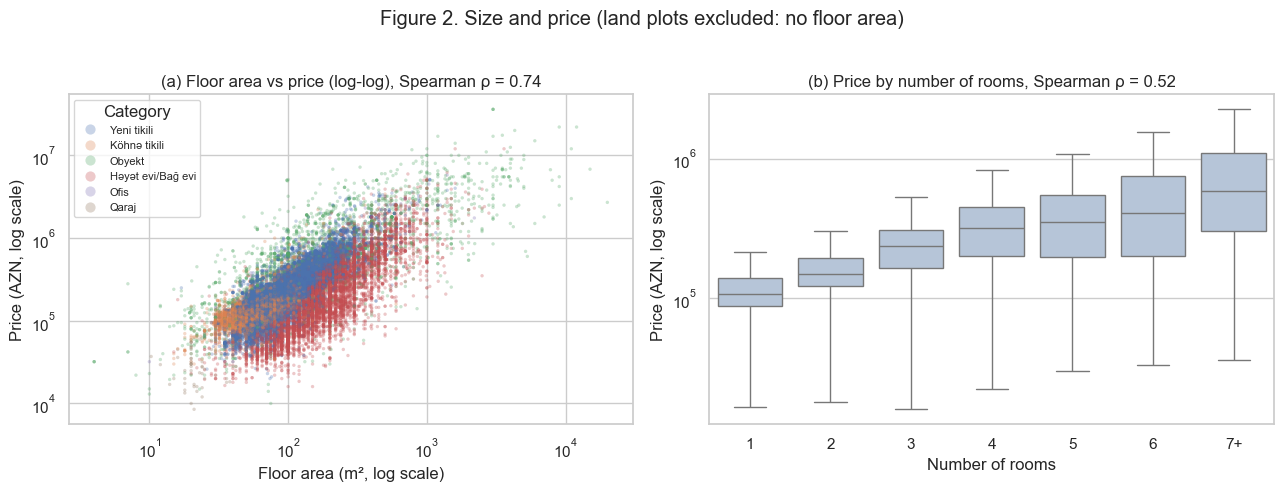

In [20]:
# Area vs price and rooms vs price (Figure 2)
buildings = clean[clean["area_m2"] > 0]   # land plots have no floor area
with_rooms = clean[clean["rooms"] > 0]    # categories with a room count

# Strength of the relationships (Spearman = rank-based, robust to outliers)
rho_area = buildings["area_m2"].corr(buildings["price"], method="spearman")
rho_rooms = with_rooms["rooms"].corr(with_rooms["price"], method="spearman")
print(f"Spearman correlation  area vs price:  {rho_area:.2f}  (n = {len(buildings):,})")
print(f"Spearman correlation  rooms vs price: {rho_rooms:.2f}  (n = {len(with_rooms):,})")

# Group rare large room counts into "7+"
rooms_group = with_rooms["rooms"].clip(upper=7).astype(str).replace("7", "7+")
order = ["1", "2", "3", "4", "5", "6", "7+"]
print("\nMedian price by rooms (AZN):")
print(with_rooms.groupby(rooms_group)["price"].agg(["count", "median"]).reindex(order).round(0))
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

# (a) Area vs price, log-log, coloured by category
sns.scatterplot(data=buildings, x="area_m2", y="price", hue="category", s=6, alpha=0.3, linewidth=0, ax=axes[0])
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_title(f"(a) Floor area vs price (log-log), Spearman ρ = {rho_area:.2f}")
axes[0].set_xlabel("Floor area (m², log scale)")
axes[0].set_ylabel("Price (AZN, log scale)")
axes[0].legend(title="Category", markerscale=3, fontsize=8)

# (b) Price by number of rooms
sns.boxplot(x=rooms_group, y=with_rooms["price"], order=order, showfliers=False, color="lightsteelblue", ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_title(f"(b) Price by number of rooms, Spearman ρ = {rho_rooms:.2f}")
axes[1].set_xlabel("Number of rooms")
axes[1].set_ylabel("Price (AZN, log scale)")
fig.suptitle("Figure 2. Size and price (land plots excluded: no floor area)", y=1.02)
plt.tight_layout()
plt.savefig("report/figures/fig2_area_rooms_vs_price.png", dpi=150, bbox_inches="tight")
plt.show()

Listings with coordinates outside Azerbaijan: 1
           category     price  city            location   lat   lng
24952  Köhnə tikili 93,800.00  bakı  5-ci mikrorayon q. 32.69 12.59

Median price by city (n >= 100):
          count     median
city                      
bakı      63207 210,000.00
xırdalan    141  93,000.00

Most expensive locations (n >= 200):
                count     median
location                        
Ağ şəhər q.       932 539,594.00
Mərdəkan q.      2326 372,500.00
İçəri Şəhər m.    803 360,000.00
Sahil m.          566 350,000.00
Nizami m.        1696 337,000.00

Cheapest locations (n >= 200):
             count    median
location                    
Hövsan q.      613 88,000.00
Saray q.       200 85,000.00
Masazır q.    1808 78,500.00
Binəqədi q.    363 74,000.00
Binə q.        631 65,000.00


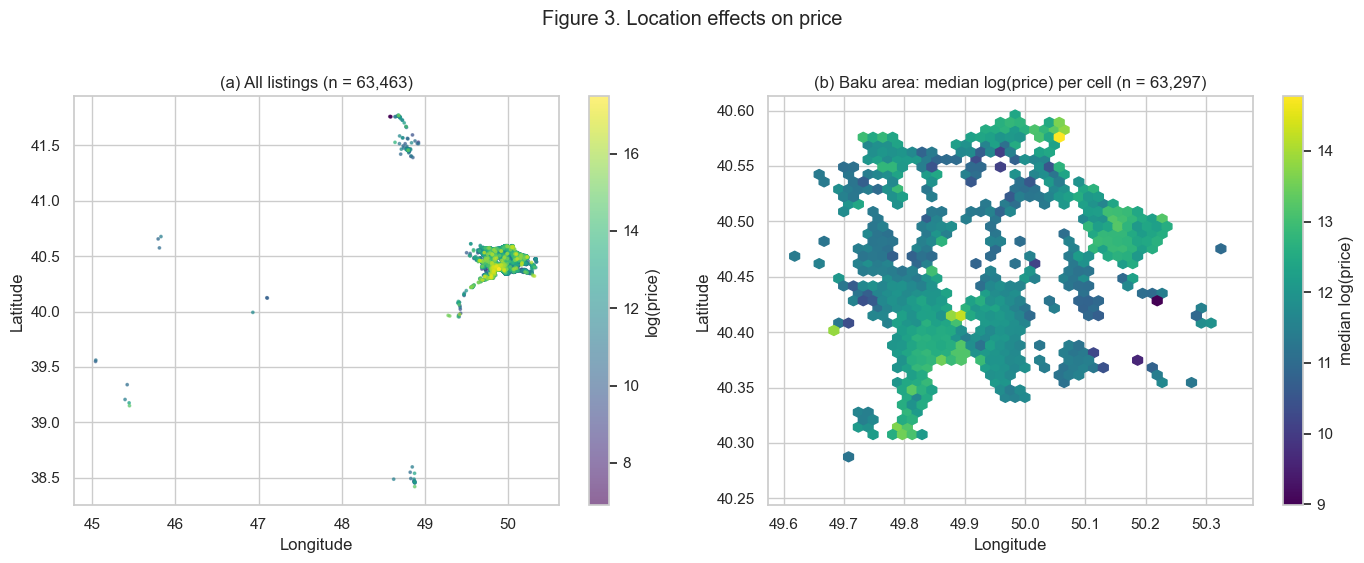

In [21]:
# Location effects using lat/lng
# Sanity check: coordinates inside Azerbaijan's bounding box
in_az = clean["lat"].between(38.3, 42.0) & clean["lng"].between(44.7, 51.0)
print(f"Listings with coordinates outside Azerbaijan: {(~in_az).sum()}")
print(clean.loc[~in_az, ["category", "price", "city", "location", "lat", "lng"]].head(10))

# Median price by city (cities with at least 100 listings)
city_stats = clean.groupby("city")["price"].agg(["count", "median"])
print("\nMedian price by city (n >= 100):")
print(city_stats[city_stats["count"] >= 100].sort_values("median", ascending=False).round(0))

# Most and least expensive Baku locations (at least 200 listings)
loc_stats = clean.groupby("location")["price"].agg(["count", "median"])
loc_stats = loc_stats[loc_stats["count"] >= 200].sort_values("median", ascending=False)
print("\nMost expensive locations (n >= 200):")
print(loc_stats.head(5).round(0))
print("\nCheapest locations (n >= 200):")
print(loc_stats.tail(5).round(0))
geo = clean[in_az]
baku = geo[geo["lat"].between(40.25, 40.65) & geo["lng"].between(49.6, 50.4)]
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# (a) Whole country: each listing coloured by log(price)
geo_sorted = geo.sort_values("log_price")   # expensive points drawn on top
sc = axes[0].scatter(geo_sorted["lng"], geo_sorted["lat"], c=geo_sorted["log_price"], cmap="viridis", s=3, alpha=0.6)
axes[0].set_title(f"(a) All listings (n = {len(geo):,})")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
fig.colorbar(sc, ax=axes[0], label="log(price)")

# (b) Baku: median log(price) per hexagon (robust to single expensive listings)
hb = axes[1].hexbin(baku["lng"], baku["lat"], C=baku["log_price"], reduce_C_function=np.median, gridsize=45, cmap="viridis", mincnt=5)
axes[1].set_title(f"(b) Baku area: median log(price) per cell (n = {len(baku):,})")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")
fig.colorbar(hb, ax=axes[1], label="median log(price)")

fig.suptitle("Figure 3. Location effects on price", y=1.02)
plt.tight_layout()
plt.savefig("report/figures/fig3_location_effects.png", dpi=150, bbox_inches="tight")
plt.show()

In [22]:
# Remove invalid coordinates, add distance-to-centre feature
rows_before = len(clean)
clean = clean[in_az].reset_index(drop=True)
print(f"Removed invalid coordinates: {rows_before - len(clean)} | Rows: {len(clean):,}")

# Fountains Square, Baku (source: Wikipedia, "Fountains Square, Baku")
CENTRE_LAT, CENTRE_LNG = 40.37083, 49.83694
def haversine_km(lat1, lng1, lat2, lng2):
    """Great-circle distance between two points on Earth, in kilometres."""
    lat1, lng1, lat2, lng2 = map(np.radians, [lat1, lng1, lat2, lng2])
    a = (np.sin((lat2 - lat1) / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin((lng2 - lng1) / 2) ** 2)
    return 6371 * 2 * np.arcsin(np.sqrt(a))

clean["dist_centre_km"] = haversine_km(clean["lat"], clean["lng"], CENTRE_LAT, CENTRE_LNG)
rho_dist = clean["dist_centre_km"].corr(clean["price"], method="spearman")
print(f"Spearman correlation  distance to centre vs price: {rho_dist:.2f}")
print(clean["dist_centre_km"].describe().round(1))

# How many distinct location labels? (decides how we encode it later)
loc_counts = clean["location"].value_counts()
print(f"\nDistinct locations: {len(loc_counts)}")
print(f"Locations with < 30 listings: {(loc_counts < 30).sum()} (covering {loc_counts[loc_counts < 30].sum()} listings)")

Removed invalid coordinates: 1 | Rows: 63,463
Spearman correlation  distance to centre vs price: -0.40
count   63,463.00
mean         9.00
std         11.40
min          0.00
25%          3.30
50%          5.20
75%         10.70
max        418.90
Name: dist_centre_km, dtype: float64

Distinct locations: 142
Locations with < 30 listings: 48 (covering 558 listings)


Price-tier threshold (train median): 210,000 AZN
                rows  share  premium (1)  standard (0)  median price
train      44,424.00   0.70         0.49          0.51    210,000.00
validation  9,519.00   0.15         0.49          0.51    210,000.00
test        9,520.00   0.15         0.49          0.51    210,000.00


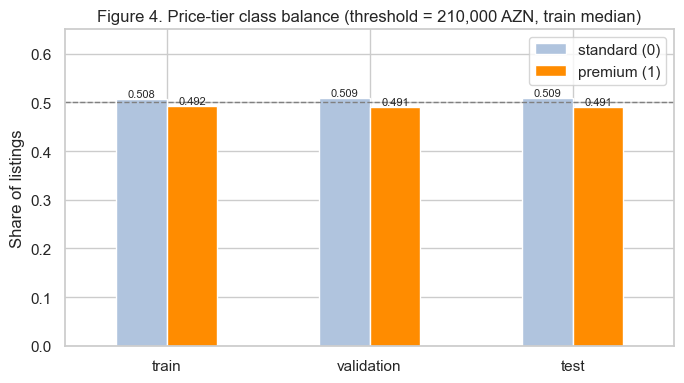

In [23]:
# Leakage-free train / validation / test split and price-tier label (Figure 4)
from sklearn.model_selection import train_test_split
# 70% train / 30% holdout, stratified by property category (a feature, not the target)
train_df, hold_df = train_test_split(clean, test_size=0.30, stratify=clean["category"], random_state=RANDOM_STATE)
# price-tier threshold = median price of the training split only
TIER_THRESHOLD = train_df["price"].median()
print(f"Price-tier threshold (train median): {TIER_THRESHOLD:,.0f} AZN")

def add_price_tier(data: pd.DataFrame) -> pd.DataFrame:
    """1 = premium (price above the train median), 0 = standard."""
    data = data.copy()
    data["price_tier"] = (data["price"] > TIER_THRESHOLD).astype(int)
    return data

train_df = add_price_tier(train_df)
hold_df = add_price_tier(hold_df)
# Step 3: split holdout 50/50 into validation and test, stratified by the price-tier label
val_df, test_df = train_test_split(hold_df, test_size=0.50, stratify=hold_df["price_tier"], random_state=RANDOM_STATE)

# Safety checks: no listing appears in two splits, nothing lost
assert set(train_df["listing_id"]).isdisjoint(val_df["listing_id"])
assert set(train_df["listing_id"]).isdisjoint(test_df["listing_id"])
assert set(val_df["listing_id"]).isdisjoint(test_df["listing_id"])
assert len(train_df) + len(val_df) + len(test_df) == len(clean)

# Split sizes and class balance (required in the report)
splits = {"train": train_df, "validation": val_df, "test": test_df}
summary = pd.DataFrame({
    name: {
        "rows": len(d),
        "share": len(d) / len(clean),
        "premium (1)": d["price_tier"].mean(),
        "standard (0)": 1 - d["price_tier"].mean(),
        "median price": d["price"].median(),
    }
    for name, d in splits.items()
}).T
print(summary.round(3))

# Figure 4: class balance per split
fig, ax = plt.subplots(figsize=(7, 4))
balance = pd.DataFrame({name: d["price_tier"].value_counts(normalize=True).sort_index() for name, d in splits.items()}).T
balance.columns = ["standard (0)", "premium (1)"]
balance.plot(kind="bar", ax=ax, color=["lightsteelblue", "darkorange"], rot=0)
ax.axhline(0.5, color="grey", linestyle="--", linewidth=1)
ax.set_title(f"Figure 4. Price-tier class balance (threshold = {TIER_THRESHOLD:,.0f} AZN, train median)")
ax.set_ylabel("Share of listings")
ax.set_ylim(0, 0.65)
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=8)
plt.tight_layout()
plt.savefig("report/figures/fig4_class_balance.png", dpi=150, bbox_inches="tight")
plt.show()

In [24]:
# Encode categoricals and scale features (fitted on TRAIN only)
from sklearn.preprocessing import StandardScaler
NUMERIC = ["area_m2", "land_area_sot", "rooms", "floor", "total_floors", "lat", "lng", "dist_centre_km"]
BINARY = ["has_bill_of_sale", "mortgage", "is_vip", "is_featured"]
CATEGORICAL = ["category", "repair", "location"]
MIN_LOCATION_COUNT = 30   # locations with fewer TRAIN listings are grouped as "other"

# Fit on train only
loc_counts_train = train_df["location"].value_counts()
frequent_locations = set(loc_counts_train[loc_counts_train >= MIN_LOCATION_COUNT].index)
def prepare_features(data: pd.DataFrame) -> pd.DataFrame:
    """Group rare locations and one-hot encode categoricals."""
    data = data.copy()
    data["location"] = data["location"].where(data["location"].isin(frequent_locations), "other")
    return pd.get_dummies(data[NUMERIC + BINARY + CATEGORICAL], columns=CATEGORICAL, dtype=int)
X_train = prepare_features(train_df)
feature_names = X_train.columns.tolist()   # the column layout is fixed by train

# Val/test get exactly the train columns (unseen categories -> all zeros)
X_val = prepare_features(val_df).reindex(columns=feature_names, fill_value=0)
X_test = prepare_features(test_df).reindex(columns=feature_names, fill_value=0)

# Targets
y_train_reg, y_val_reg, y_test_reg = train_df["log_price"], val_df["log_price"], test_df["log_price"]
y_train_clf, y_val_clf, y_test_clf = train_df["price_tier"], val_df["price_tier"], test_df["price_tier"]

# Scaled copies for the SVM (scaler fitted on train only); the tree uses unscaled features
scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Checks
assert X_train.isna().sum().sum() == 0 and X_val.isna().sum().sum() == 0 and X_test.isna().sum().sum() == 0
assert list(X_val.columns) == list(X_test.columns) == feature_names
print(f"Frequent locations kept: {len(frequent_locations)} (others -> 'other')")
print(f"Number of features: {len(feature_names)}")
print(f"X_train {X_train.shape} | X_val {X_val.shape} | X_test {X_test.shape}")
print(f"Listings mapped to 'other' location: train {(X_train['location_other'] == 1).sum()}, "
      f"val {(X_val['location_other'] == 1).sum()}, test {(X_test['location_other'] == 1).sum()}")
print("\nScaled train features: mean ≈ 0, std ≈ 1 ->", round(X_train_scaled.mean(), 3), round(X_train_scaled.std(), 3))

Frequent locations kept: 90 (others -> 'other')
Number of features: 113
X_train (44424, 113) | X_val (9519, 113) | X_test (9520, 113)
Listings mapped to 'other' location: train 506, val 107, test 105

Scaled train features: mean ≈ 0, std ≈ 1 -> -0.0 1.0
